# BU versus Gou on a three-dimensional p-value grid

This notebook evaluates the current Python implementations of:

- BU $\Pi_{\mathrm{mix}}(0.3)$ from `cms_bottomup.py` and `simulate_cms_normal.py`;
- Gou's GTXR procedure from `gou_gtxr.py`.

It constructs a grid of three p-values in $[0, 0.3]^3$, applies both procedures, and saves the configurations for which BU rejects more hypotheses than Gou.

Run the notebook with the repository directory as the working directory so that `Path.cwd()` points to the Python modules and threshold files.

In [1]:
from pathlib import Path
from statistics import NormalDist
import importlib
import json

import numpy as np
import pandas as pd

try:
    from IPython.display import display
except ModuleNotFoundError:
    def display(value):
        print(value)

PROJECT_DIR = Path.cwd()
THRESHOLD_FILE = PROJECT_DIR / "cms_thresholds_K3.json"
OUTPUT_FILE = PROJECT_DIR / "bu_better.csv"

cms_mod = importlib.import_module("cms_bottomup")
sim_mod = importlib.import_module("simulate_cms_normal")
gou_mod = importlib.import_module("gou_gtxr")

importlib.reload(cms_mod)
importlib.reload(sim_mod)
importlib.reload(gou_mod)

K = 3
ALPHA = 0.05
TARGET_POWER = 0.3
B_THRESHOLD = 1_000_000
THRESHOLD_SEED = 123
THRESHOLD_CHUNK_SIZE = 20_000
N_JOBS = -1
GRID_SIZE = 30
GRID_LOWER = 0.0
GRID_UPPER = 0.3

print("Project directory:", PROJECT_DIR)
print("Threshold file:", THRESHOLD_FILE)

Project directory: /Users/rajeshkarmakar/Downloads/BUStrongControl
Threshold file: /Users/rajeshkarmakar/Downloads/BUStrongControl/cms_thresholds_K3.json


## Load or estimate the BU thresholds

The BU procedure requires $[t_2,t_3]$ calibrated specifically for $K=3$. If `cms_thresholds_K3.json` exists, this cell validates and loads it. Otherwise, it estimates the thresholds under independent uniform null p-values and saves them for later runs.

For the normal lower-tail alternative,

$$
\theta=\Phi^{-1}(\alpha/K)-\Phi^{-1}(0.3),
$$

with $f(u)=g_\theta(u)$ and $h(u)=1+g_\theta(u)$ for $\Pi_{\mathrm{mix}}$.

In [2]:
normal = NormalDist()
theta = normal.inv_cdf(ALPHA / K) - normal.inv_cdf(TARGET_POWER)


def f(u):
    return sim_mod.g_theta_normal_p(u, theta)


def h(u):
    return 1.0 + sim_mod.g_theta_normal_p(u, theta)


if THRESHOLD_FILE.exists():
    with THRESHOLD_FILE.open("r", encoding="utf-8") as f_in:
        threshold_payload = json.load(f_in)

    params = threshold_payload["params"]
    if int(params["K"]) != K:
        raise ValueError(f"Expected K={K}; found K={params['K']}.")
    if not np.isclose(float(params["alpha"]), ALPHA):
        raise ValueError("The saved alpha does not match ALPHA.")
    if params.get("alternative", "normal") != "normal":
        raise ValueError("This notebook requires normal-alternative thresholds.")

    matching = [
        spec
        for spec in threshold_payload["bu_procedures"]
        if spec["objective"] == "bayes"
        and np.isclose(float(spec["target_power"]), TARGET_POWER)
    ]
    if len(matching) != 1:
        raise ValueError(
            "Expected exactly one BU bayes procedure with target power 0.3."
        )

    specification = matching[0]
    if "theta" in specification and not np.isclose(
        float(specification["theta"]), theta
    ):
        raise ValueError("The saved theta is not calibrated for K=3.")
    thresholds = np.asarray(
        specification["thresholds_t2_to_tK"], dtype=float
    )
    print("Loaded existing thresholds.")
else:
    thresholds = cms_mod.estimate_cms_thresholds(
        K=K,
        B=B_THRESHOLD,
        f=f,
        h=h,
        alpha=ALPHA,
        seed=THRESHOLD_SEED,
        chunk_size=THRESHOLD_CHUNK_SIZE,
        n_jobs=N_JOBS,
        null_correlation_phi=0.0,
        verbose=True,
    )

    threshold_payload = {
        "params": {
            "K": K,
            "alpha": ALPHA,
            "procedure_target_powers": {"bayes": [TARGET_POWER]},
            "alternative": "normal",
            "null_correlation_phi": 0.0,
            "B_threshold": B_THRESHOLD,
            "seed": THRESHOLD_SEED,
            "n_jobs": N_JOBS,
            "chunk_size": THRESHOLD_CHUNK_SIZE,
        },
        "bu_procedures": [
            {
                "name": "BU_bayes_tp_0p3",
                "objective": "bayes",
                "target_power": TARGET_POWER,
                "theta": float(theta),
                "thresholds_t2_to_tK": thresholds.tolist(),
            }
        ],
    }
    with THRESHOLD_FILE.open("w", encoding="utf-8") as f_out:
        json.dump(threshold_payload, f_out, indent=2)
    print("Saved thresholds:", THRESHOLD_FILE)

if thresholds.size != K - 1:
    raise ValueError(f"Expected {K - 1} thresholds; found {thresholds.size}.")

print("theta:", theta)
print("thresholds [t2, t3]:", thresholds)

Loaded existing thresholds.
theta: -1.6036447214769434
thresholds [t2, t3]: [ 9.380983   14.76062866]


## Construct the p-value grid

With `GRID_SIZE = 30`, the grid contains $30^3=27{,}000$ p-value vectors.

In [3]:
grid_values = np.linspace(GRID_LOWER, GRID_UPPER, GRID_SIZE)
mesh = np.meshgrid(*([grid_values] * K), indexing="ij")
points = np.stack(mesh, axis=-1).reshape(-1, K)

print("Grid shape:", points.shape)
print("First five points:")
print(points[:5])

Grid shape: (27000, 3)
First five points:
[[0.         0.         0.        ]
 [0.         0.         0.01034483]
 [0.         0.         0.02068966]
 [0.         0.         0.03103448]
 [0.         0.         0.04137931]]


## Apply Gou and BU

Both methods return decisions in the original p-value order. A value of `1` denotes rejection.

In [4]:
gou_decisions = gou_mod.gou_gtxr_batch(points, alpha=ALPHA)

bu_decisions = np.vstack(
    [
        sim_mod.apply_procedure_one_sample(
            pvals=row,
            thresholds_t2_to_tk=thresholds,
            f=f,
            h=h,
            alpha=ALPHA,
        )
        for row in points
    ]
)

pvalue_columns = [f"p{i}" for i in range(1, K + 1)]
gou_columns = [f"Gou_D{i}" for i in range(1, K + 1)]
bu_columns = [f"BU_mix_0p3_D{i}" for i in range(1, K + 1)]

result = pd.concat(
    [
        pd.DataFrame(points, columns=pvalue_columns),
        pd.DataFrame(gou_decisions, columns=gou_columns, dtype=int),
        pd.DataFrame(bu_decisions, columns=bu_columns, dtype=int),
    ],
    axis=1,
)

print("Evaluated configurations:", len(result))
display(result.head())

Evaluated configurations: 27000


,p1,p2,p3,Gou_D1,Gou_D2,Gou_D3,BU_mix_0p3_D1,BU_mix_0p3_D2,BU_mix_0p3_D3
0,0.0,0.0,0.000000,1,1,1,1,1,1
1,0.0,0.0,0.010345,1,1,1,1,1,1
2,0.0,0.0,0.020690,1,1,1,1,1,1
3,0.0,0.0,0.031034,1,1,1,1,1,1
4,0.0,0.0,0.041379,1,1,1,1,1,1


## Keep configurations where BU makes more discoveries

In [5]:
gou_discoveries = result[gou_columns].sum(axis=1)
bu_discoveries = result[bu_columns].sum(axis=1)

bu_better = result.loc[bu_discoveries > gou_discoveries].copy()

print("Configurations where BU is better:", len(bu_better))
print("Output shape:", bu_better.shape)
display(bu_better.head())

Configurations where BU is better: 5031
Output shape: (5031, 9)


,p1,p2,p3,Gou_D1,Gou_D2,Gou_D3,BU_mix_0p3_D1,BU_mix_0p3_D2,BU_mix_0p3_D3
95,0.0,0.031034,0.051724,1,0,0,1,1,0
96,0.0,0.031034,0.062069,1,0,0,1,1,0
97,0.0,0.031034,0.072414,1,0,0,1,1,0
98,0.0,0.031034,0.082759,1,0,0,1,1,0
99,0.0,0.031034,0.093103,1,0,0,1,1,0


In [6]:
bu_better.to_csv(OUTPUT_FILE, index=False, float_format="%.6f")
print("Saved:", OUTPUT_FILE)

Saved: /Users/rajeshkarmakar/Downloads/BUStrongControl/bu_better.csv


## Plot the rejection policy for the third coordinate

This figure compares rejection of the original third coordinate, $p_3$, by Gou and BU $\Pi_{\mathrm{mix}}(0.3)$. The horizontal axes cover $p_1,p_2\in[0,1]$. The vertical axis uses the discrete levels $p_3=0.01,0.02,\ldots,0.06$ so the rejection-region layers remain visible.

Points where neither method rejects $p_3$ are omitted. The plot uses:

- black: both methods reject $p_3$;
- red: only Gou rejects $p_3$;
- green: only BU $\Pi_{\mathrm{mix}}(0.3)$ rejects $p_3$.

Evaluated 5000/61206 plot points
Evaluated 10000/61206 plot points
Evaluated 15000/61206 plot points
Evaluated 20000/61206 plot points
Evaluated 25000/61206 plot points
Evaluated 30000/61206 plot points
Evaluated 35000/61206 plot points
Evaluated 40000/61206 plot points
Evaluated 45000/61206 plot points
Evaluated 50000/61206 plot points
Evaluated 55000/61206 plot points
Evaluated 60000/61206 plot points
Evaluated 61206/61206 plot points


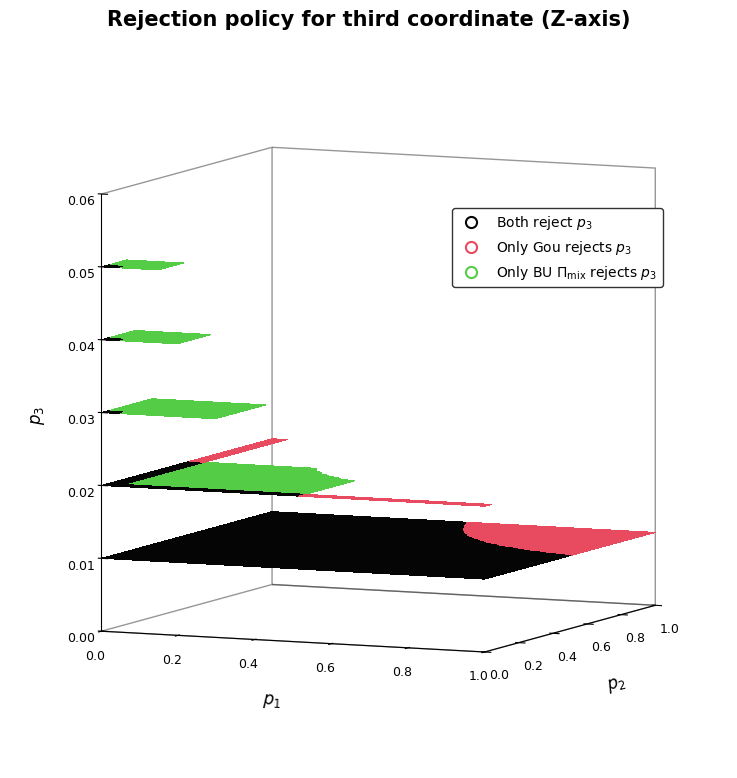

Category counts:
  both: 8937
  gou_only: 2132
  bu_only: 3528
Saved: /Users/rajeshkarmakar/Downloads/BUStrongControl/rejection_policy_third_coordinate.png


In [7]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

P12_GRID_SIZE = 101
P3_LEVELS = np.arange(0.01, 0.061, 0.01)
PLOT_BATCH_SIZE = 5_000
PLOT_FILE = PROJECT_DIR / "rejection_policy_third_coordinate.png"

# Evaluate decisions at cell centers, then render adjacent cells as solid patches.
p12_edges = np.linspace(0.0, 1.0, P12_GRID_SIZE + 1)
p12_centers = 0.5 * (p12_edges[:-1] + p12_edges[1:])
plot_mesh = np.meshgrid(
    p12_centers,
    p12_centers,
    P3_LEVELS,
    indexing="ij",
)
plot_points = np.stack(plot_mesh, axis=-1).reshape(-1, K)

plot_gou_parts = []
plot_bu_parts = []
for start in range(0, len(plot_points), PLOT_BATCH_SIZE):
    stop = min(start + PLOT_BATCH_SIZE, len(plot_points))
    batch = plot_points[start:stop]

    plot_gou_parts.append(
        gou_mod.gou_gtxr_batch(batch, alpha=ALPHA)
    )
    plot_bu_parts.append(
        np.vstack(
            [
                sim_mod.apply_procedure_one_sample(
                    pvals=row,
                    thresholds_t2_to_tk=thresholds,
                    f=f,
                    h=h,
                    alpha=ALPHA,
                )
                for row in batch
            ]
        )
    )
    print(f"Evaluated {stop}/{len(plot_points)} plot points")

plot_gou_decisions = np.vstack(plot_gou_parts)
plot_bu_decisions = np.vstack(plot_bu_parts)

# Column 2 is the decision for the original third coordinate, even after sorting.
gou_rejects_p3 = plot_gou_decisions[:, 2].astype(bool)
bu_rejects_p3 = plot_bu_decisions[:, 2].astype(bool)

plot_categories = {
    "both": gou_rejects_p3 & bu_rejects_p3,
    "gou_only": gou_rejects_p3 & ~bu_rejects_p3,
    "bu_only": ~gou_rejects_p3 & bu_rejects_p3,
}

colors = {
    "both": "#050505",
    "gou_only": "#e84a5f",
    "bu_only": "#55cc45",
}
labels = {
    "both": r"Both reject $p_3$",
    "gou_only": r"Only Gou rejects $p_3$",
    "bu_only": r"Only BU $\Pi_{\mathrm{mix}}$ rejects $p_3$",
}


def solid_rectangles(mask, x_edges, y_edges, z_value):
    """Merge contiguous true cells along p1 into gap-free rectangles."""
    rectangles = []
    for y_index in range(mask.shape[1]):
        padded = np.concatenate(([False], mask[:, y_index], [False]))
        changes = np.diff(padded.astype(np.int8))
        starts = np.flatnonzero(changes == 1)
        stops = np.flatnonzero(changes == -1)
        for start, stop in zip(starts, stops):
            rectangles.append(
                [
                    (x_edges[start], y_edges[y_index], z_value),
                    (x_edges[stop], y_edges[y_index], z_value),
                    (x_edges[stop], y_edges[y_index + 1], z_value),
                    (x_edges[start], y_edges[y_index + 1], z_value),
                ]
            )
    return rectangles


category_grids = {
    category: mask.reshape(P12_GRID_SIZE, P12_GRID_SIZE, len(P3_LEVELS))
    for category, mask in plot_categories.items()
}

fig = plt.figure(figsize=(9, 8), facecolor="white")
ax = fig.add_subplot(111, projection="3d")
ax.set_proj_type("ortho")

# Solid polygon patches avoid the dotted/checkerboard appearance of 3D scatter.
for level_index, p3_value in enumerate(P3_LEVELS):
    for category in ("bu_only", "gou_only", "both"):
        rectangles = solid_rectangles(
            category_grids[category][:, :, level_index],
            p12_edges,
            p12_edges,
            float(p3_value),
        )
        if rectangles:
            collection = Poly3DCollection(
                rectangles,
                facecolors=colors[category],
                edgecolors="none",
                linewidths=0.0,
                antialiaseds=False,
                alpha=1.0,
            )
            ax.add_collection3d(collection)

legend_handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="none",
        markerfacecolor="none",
        markeredgecolor=colors[category],
        markeredgewidth=1.5,
        markersize=8,
        label=labels[category],
    )
    for category in ("both", "gou_only", "bu_only")
]

ax.set_title(
    "Rejection policy for third coordinate (Z-axis)",
    fontsize=15,
    fontweight="bold",
    pad=18,
)
ax.set_xlabel(r"$p_1$", fontsize=12, labelpad=12)
ax.set_ylabel(r"$p_2$", fontsize=12, labelpad=12)
ax.set_zlabel(r"$p_3$", fontsize=12, labelpad=10)
ax.set_xlim(0.0, 1.0)
ax.set_ylim(0.0, 1.0)
ax.set_zlim(0.0, 0.06)
ax.set_xticks(np.linspace(0.0, 1.0, 6))
ax.set_yticks(np.linspace(0.0, 1.0, 6))
ax.set_zticks(np.arange(0.0, 0.061, 0.01))
ax.tick_params(labelsize=9, pad=2)
# Match the reference's low, tilted viewpoint while keeping strips separated.
ax.set_box_aspect((1.0, 1.0, 1.05))
ax.view_init(elev=7, azim=-66)
ax.zaxis._axinfo["juggled"] = (1, 2, 0)  # Display p3 on the left.

# Keep the bounding box while removing distracting pane fills and grid lines.
for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
    axis.pane.fill = False
    axis.pane.set_edgecolor("#303030")
ax.grid(False)

ax.legend(
    handles=legend_handles,
    loc="upper right",
    bbox_to_anchor=(0.92, 0.79),
    frameon=True,
    facecolor="white",
    edgecolor="#333333",
    framealpha=1.0,
    fontsize=10,
)

fig.tight_layout(pad=1.5)
fig.savefig(PLOT_FILE, dpi=220, bbox_inches="tight", facecolor="white")
plt.show()

print("Category counts:")
for category, mask in plot_categories.items():
    print(f"  {category}: {int(mask.sum())}")
print("Saved:", PLOT_FILE)

## Rejection-count regions by fixed third p-value

The top row shows Gou and the bottom row shows BU $\Pi_{\mathrm{mix}}$. Colors indicate the exact number of rejected hypotheses.


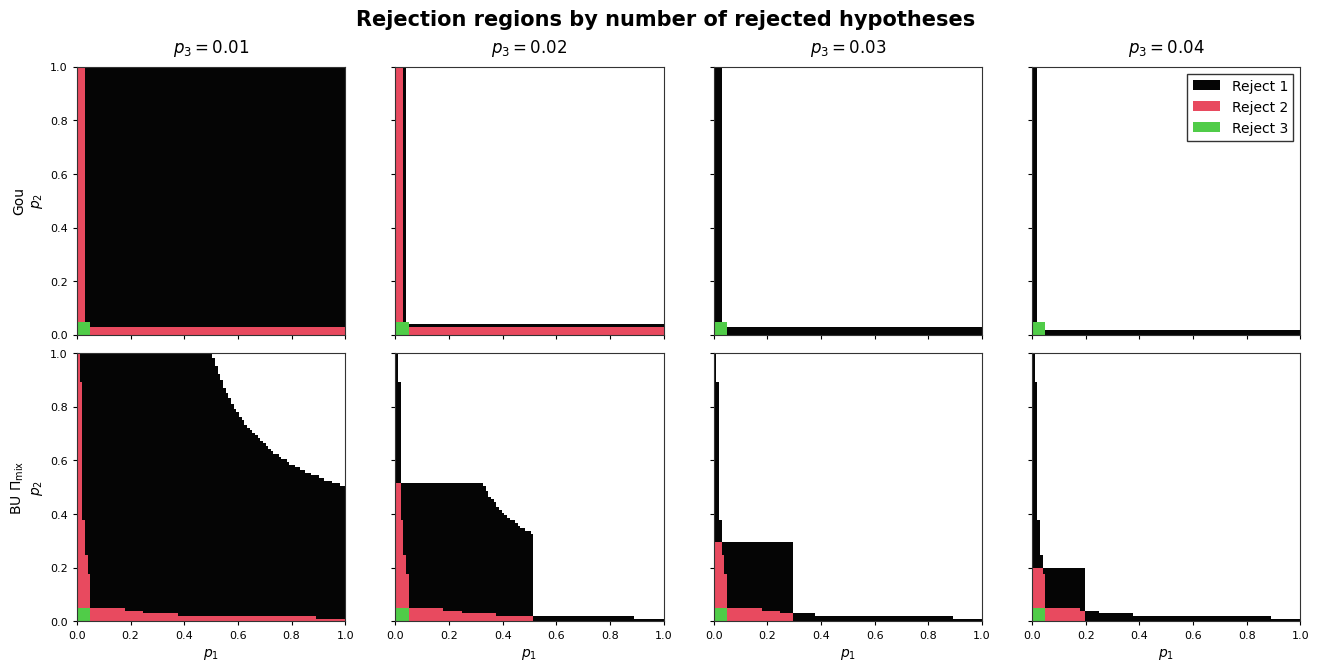

Saved: /Users/rajeshkarmakar/Downloads/BUStrongControl/rejection_count_regions_gou_vs_bu.png


In [8]:
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib.patches import Patch

REJECTION_COUNT_LEVELS = np.array([0.01, 0.02, 0.03, 0.04])
REJECTION_COUNT_FILE = PROJECT_DIR / "rejection_count_regions_gou_vs_bu.png"

# Counts are invariant to the ordering used internally by each procedure.
gou_count_grid = plot_gou_decisions.sum(axis=1).reshape(
    P12_GRID_SIZE,
    P12_GRID_SIZE,
    len(P3_LEVELS),
)
bu_count_grid = plot_bu_decisions.sum(axis=1).reshape(
    P12_GRID_SIZE,
    P12_GRID_SIZE,
    len(P3_LEVELS),
)

count_colors = ["#ffffff", "#050505", "#e84a5f", "#50cc48"]
count_cmap = ListedColormap(count_colors)
count_norm = BoundaryNorm(np.arange(-0.5, 4.5, 1.0), count_cmap.N)

fig_counts, axes = plt.subplots(
    2,
    4,
    figsize=(13.2, 6.6),
    sharex=True,
    sharey=True,
    constrained_layout=True,
)

for column, p3_value in enumerate(REJECTION_COUNT_LEVELS):
    level_index = int(np.flatnonzero(np.isclose(P3_LEVELS, p3_value))[0])

    for row, count_grid in enumerate((gou_count_grid, bu_count_grid)):
        ax_panel = axes[row, column]
        ax_panel.pcolormesh(
            p12_edges,
            p12_edges,
            count_grid[:, :, level_index].T,
            cmap=count_cmap,
            norm=count_norm,
            shading="flat",
            rasterized=True,
        )
        ax_panel.set_xlim(0.0, 1.0)
        ax_panel.set_ylim(0.0, 1.0)
        ax_panel.set_aspect("equal", adjustable="box")
        ax_panel.set_xticks(np.linspace(0.0, 1.0, 6))
        ax_panel.set_yticks(np.linspace(0.0, 1.0, 6))
        ax_panel.tick_params(labelsize=8, direction="out", length=3)

        for spine in ax_panel.spines.values():
            spine.set_linewidth(0.8)
            spine.set_color("#333333")

    axes[0, column].set_title(rf"$p_3 = {p3_value:.2f}$", fontsize=12, pad=10)
    axes[1, column].set_xlabel(r"$p_1$", fontsize=10)

axes[0, 0].set_ylabel("Gou\n" + r"$p_2$", fontsize=10)
axes[1, 0].set_ylabel(r"BU $\Pi_{\mathrm{mix}}$" + "\n" + r"$p_2$", fontsize=10)

legend_handles = [
    Patch(facecolor=count_colors[count], edgecolor="none", label=f"Reject {count}")
    for count in (1, 2, 3)
]
axes[0, 3].legend(
    handles=legend_handles,
    loc="upper right",
    frameon=True,
    fancybox=False,
    facecolor="white",
    edgecolor="#333333",
    framealpha=1.0,
    fontsize=10,
)

fig_counts.suptitle(
    "Rejection regions by number of rejected hypotheses",
    fontsize=15,
    fontweight="bold",
)
fig_counts.savefig(
    REJECTION_COUNT_FILE,
    dpi=220,
    bbox_inches="tight",
    facecolor="white",
)
plt.show()
print("Saved:", REJECTION_COUNT_FILE)
